In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Cleaning Data

In [2]:
#data
dfOld = pd.read_stata("Data/Flooded Cities/data.dta")
dfOld = dfOld.dropna()
dfData = dfOld.copy()
dfData.head()

,grid_identifier,dist_river,dist_coast,popdens1995,popdens1990,popdens2000,flood_2003,flood_2004,flood_2005,flood_2006,...,light1995,light1994,light1993,light1992,elevation,country,flare,x,y,urban_area_indicator
185,209,149.936203,14.923289,0.763984,0.721588,0.769551,0,0,0,0,...,21,16,0,0,239,Chile,1.0,-68.695000,-53.239300,8932.0
186,210,152.002975,12.005061,0.763984,0.721588,0.769551,0,0,0,0,...,14,7,10,0,239,Chile,1.0,-68.667999,-53.239300,8933.0
187,211,152.698761,11.042063,0.763984,0.721588,0.769551,0,0,0,0,...,9,9,0,0,239,Chile,1.0,-68.658997,-53.239300,8933.0
199,223,146.427917,17.631695,0.763984,0.721588,0.769551,0,0,0,0,...,8,24,9,16,239,Chile,1.0,-68.721901,-53.209202,8930.0
200,224,147.109314,16.633770,0.763984,0.721588,0.769551,0,0,0,0,...,6,19,9,13,239,Chile,1.0,-68.712898,-53.209202,8930.0


In [3]:
#india
dfOld = pd.read_stata("Data/Flooded Cities/india.dta")
dfOld = dfOld.dropna()
dfIndia = dfOld.copy()
dfIndia.head()


,district,year,state,area,one,maxrain,light,per_capita_income_rs_,flood,population_in_hundreds_,ddp_rs_lakhs_current_,distnum,gdp,pop,per,lngdp,lnpop,lnpercap,lnlight,flood_indicator
3,24-Parganas(N),2003,West Bengal,5810.193848,818.0,307.928131,24.661369,23800.0,0.009780,94190.0,2241768.0,1.0,2.181842e+11,9371325.0,23282.109375,26.108606,16.053165,10.055441,3.205238,1.0
4,24-Parganas(N),2004,West Bengal,5810.193848,818.0,339.277740,25.943766,26094.0,0.013447,96136.0,2508604.0,1.0,2.441895e+11,9564950.0,25529.615234,26.221210,16.073616,10.147594,3.255931,1.0
5,24-Parganas(N),2005,West Bengal,5810.193848,818.0,283.513092,27.850855,29648.0,0.000000,98122.0,2909091.0,1.0,2.808969e+11,9762550.0,28772.906250,26.361254,16.094065,10.267189,3.326864,0.0
6,24-Parganas(N),2006,West Bengal,5810.193848,818.0,479.050476,26.815403,33554.0,0.000000,100150.0,3360434.0,1.0,3.247598e+11,9964300.0,32592.335938,26.506351,16.114519,10.391832,3.288976,0.0
10,24-Parganas(S),2003,West Bengal,5527.109375,722.0,375.594879,21.530472,20888.0,0.000000,72530.0,1514984.0,2.0,1.498228e+11,7218975.0,20754.027344,25.732719,15.792224,9.940495,3.069469,0.0


### Initial Analysis

In [9]:
dfData['flood_total'] = dfData[['flood_2003','flood_2004','flood_2005','flood_2006']].sum(axis=1)
dfData.groupby('flood_total')['popdens2000'].mean()
dfData[['flood_total','dist_river']].corr()
dfData.groupby('flood_total')['elevation'].mean()
dfData.groupby('flood_total')['light1995'].mean()


flood_total
0    22.15408
1     8.00000
Name: light1995, dtype: float64

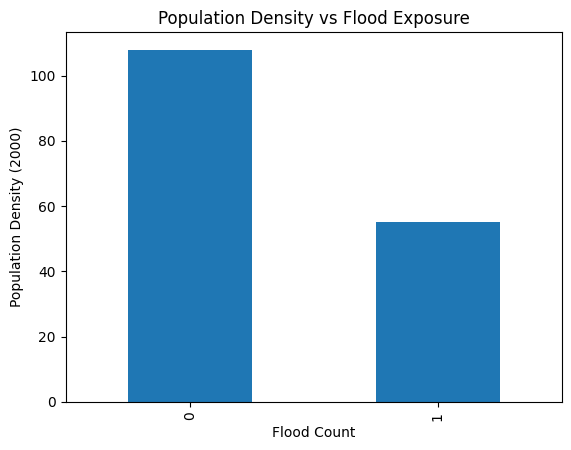

In [10]:
dfData.groupby('flood_total')['popdens2000'].mean().plot(kind='bar')
plt.title("Population Density vs Flood Exposure")
plt.ylabel("Population Density (2000)")
plt.xlabel("Flood Count")
plt.show()